In [1]:
import pandas as pd

### Lectura de archivo fuente

In [18]:
df = pd.read_csv("../data/raw/transacciones_igac.csv")

### Exploración de datos

In [19]:
df.head()

,year_radica,count_a,count_de,tipo_predio_zona,categoria_ruralidad_2024,valor
0,2023,2,2,URBANO,Ciudades y aglomeraciones,530000000.0
1,2023,2,2,URBANO,Ciudades y aglomeraciones,400000000.0
2,2023,2,2,URBANO,Ciudades y aglomeraciones,400000000.0
3,2023,2,2,URBANO,Ciudades y aglomeraciones,400000000.0
4,2021,1,1,URBANO,Ciudades y aglomeraciones,380000000.0


In [20]:
df.shape

(5000, 6)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year_radica               5000 non-null   int64  
 1   count_a                   5000 non-null   int64  
 2   count_de                  5000 non-null   int64  
 3   tipo_predio_zona          5000 non-null   str    
 4   categoria_ruralidad_2024  5000 non-null   str    
 5   valor                     5000 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 384.8 KB


In [24]:
df.describe()

,year_radica,count_a,count_de,valor
count,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2022.027800,1.349600,1.539200,4.371646e+08
std,0.941066,0.803436,1.322729,5.697717e+08
min,2015.000000,0.000000,1.000000,1.000000e+02
25%,2021.000000,1.000000,1.000000,1.550000e+08
50%,2022.000000,1.000000,1.000000,3.000000e+08
75%,2023.000000,2.000000,2.000000,5.500000e+08
max,2023.000000,30.000000,32.000000,1.306920e+10


### Validación de valores nulos

In [36]:
df.isnull().sum()

year_radica                 0
count_a                     0
count_de                    0
tipo_predio_zona            0
categoria_ruralidad_2024    0
valor                       0
dtype: int64

### Validación de campos para determinar relevancia

In [26]:
df["tipo_predio_zona"].value_counts()

tipo_predio_zona
URBANO             4959
RURAL                38
SIN INFORMACION       3
Name: count, dtype: int64

In [27]:
df["categoria_ruralidad_2024"].value_counts()

categoria_ruralidad_2024
Ciudades y aglomeraciones    4934
Intermedio                     42
Rural                          16
Rural disperso                  8
Name: count, dtype: int64

### Limpieza de datos con categoria Sin Información

In [42]:
df_modelo = df[df["tipo_predio_zona"] != "SIN INFORMACION"].copy()

### Categrización de variable a numero

In [43]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=["tipo_predio_zona"],
    drop_first=True
)

In [45]:
df_modelo.columns

Index(['year_radica', 'count_a', 'count_de', 'categoria_ruralidad_2024',
       'valor', 'tipo_predio_zona_URBANO'],
      dtype='str')

### Definición de campos que estan dentro del modelo

In [46]:
df_modelo = df_modelo[
    [
        "year_radica",
        "count_a",
        "count_de",
        "valor",
        "tipo_predio_zona_URBANO"
    ]
]

df_modelo.columns

### Creación de X - Predictores

In [48]:
X = df_modelo[
    [
        "year_radica",
        "count_a",
        "count_de",
        "tipo_predio_zona_URBANO"
    ]
]

### Conversion de True a numeros

In [56]:
X["tipo_predio_zona_URBANO"] = X["tipo_predio_zona_URBANO"].astype(int)

### Creación de Y - Campo a predecir

In [58]:
y = df_modelo["valor"]

### Validación de X y Y

In [57]:
X.head()

,year_radica,count_a,count_de,tipo_predio_zona_URBANO
0,2023,2,2,1
1,2023,2,2,1
2,2023,2,2,1
3,2023,2,2,1
4,2021,1,1,1


In [59]:
y.head()

0    530000000.0
1    400000000.0
2    400000000.0
3    400000000.0
4    380000000.0
Name: valor, dtype: float64

### Definición de train y test con Scikit 80, 20

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [62]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (3997, 4)
Datos de prueba: (1000, 4)


### Regresión Lineal

In [64]:
from sklearn.linear_model import LinearRegression

In [65]:
modelo = LinearRegression()

In [66]:
##Aprende de estos datos
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1.35e+07,2.07e+07,2.61e+07,2.12e+08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['year_radica','count_a','count_de','tipo_predio_zona_URBANO']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.708e+10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [67]:
modelo.coef_

array([1.34697408e+07, 2.07498588e+07, 2.60651704e+07, 2.12226554e+08])

In [68]:
modelo.intercept_

np.float64(-27079517251.689053)

In [69]:
y_pred = modelo.predict(X_test)

In [70]:
print("Primeros valores reales:")
print(y_test.head().values)

print("\nPrimeras predicciones:")
print(y_pred[:5])

Primeros valores reales:
[2.15e+08 5.50e+07 2.35e+08 5.90e+08 3.09e+08]

Primeras predicciones:
[5.85200994e+08 4.49559831e+08 4.15340231e+08 4.41405402e+08
 4.15340231e+08]


### Calculo de las metricas

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [73]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 316834491.79212505
MSE: 3.500891565734916e+17
RMSE: 591683324.5693946
R²: -0.0010090437994052515


In [74]:
residuos = y_test - y_pred

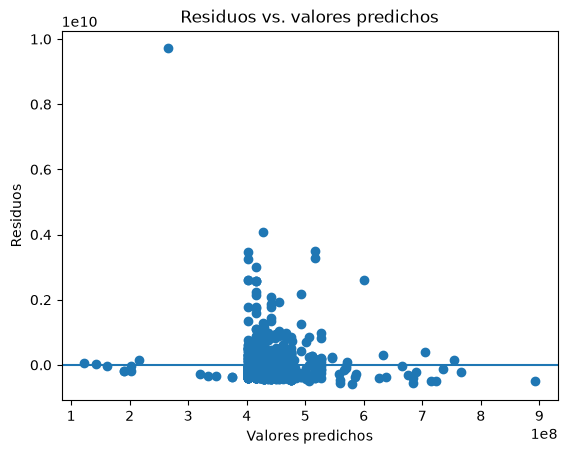

In [75]:
plt.scatter(y_pred, residuos)
plt.axhline(y=0)
plt.title("Residuos vs. valores predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.show()

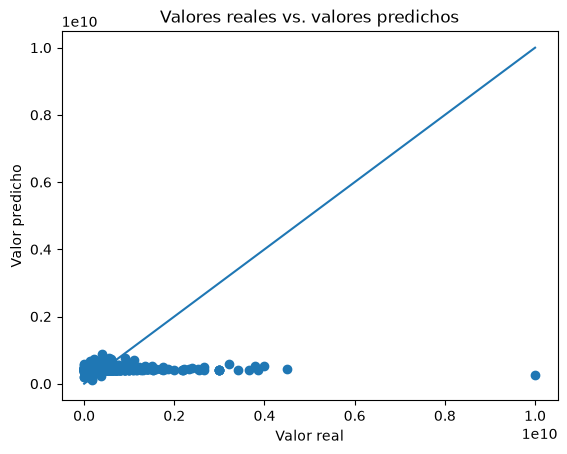

In [76]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Valores reales vs. valores predichos")

minimo = min(y_test.min(), y_pred.min())
maximo = max(y_test.max(), y_pred.max())

plt.plot([minimo, maximo], [minimo, maximo])

plt.show()